# CVAE-H baseline: CIFAR-10 quadrant inpainting

A hypernetwork maps **class label** $c$ to layer-wise scale/bias modulations for an MLP encoder and decoder. The encoder sees **visible RGB pixels** and a **pixel mask**; the decoder predicts the full flattened image (Gaussian / MSE reconstruction on normalized inputs).

**Inpainting:** Each $32 \times 32$ RGB image is split into four $16 \times 16$ quadrants. Training samples use **1, 2, or 3 visible quadrants** (remaining masked). Loss: **MSE on missing pixels** + **$\beta_t$ · KL** with **$\beta$ linear from 0 → 1** over epochs. **No early stopping.**

**Eval:** Metrics (**MSE**, **L1**, **PSNR** on denormalized $[0,1]$ images) broken out by **1 / 2 / 3 quadrants missing**.

In [26]:
import pickle
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import matplotlib.pyplot as plt
import numpy as np
import random
import time


## Hyperparameters

In [27]:
H, W, C = 32, 32, 3
SPATIAL = H * W
OUT_DIM = C * SPATIAL
ENC_IN = 2 * OUT_DIM

LATENT_DIM = 16
NUM_CLASSES = 10
COND_DIM = NUM_CLASSES

ENC_H1, ENC_H2 = 256, 128
DEC_H1, DEC_H2 = 128, 256
HYPER_HIDDEN = 256

BATCH_SIZE = 128
NUM_EPOCHS = 5
LR = 3e-4

MAX_TRAIN_SAMPLES = None

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print("=" * 60)
print("CVAE-H | CIFAR-10 | quadrant inpainting")
print("=" * 60)

Device: cpu
CVAE-H | CIFAR-10 | quadrant inpainting


## Quadrant masks (spatial → CHW-flat)

Tensor layout is **channels-first**: `x.view(B, -1)` is `[R-plane][G-plane][B-plane]`, each plane row-major. The same spatial mask is applied to all three channels.

In [28]:
def build_quadrant_spatial_masks(h=H, w=W, device=None):
    hh, ww = h // 2, w // 2
    masks = []
    for q in range(4):
        m = torch.zeros(h, w, device=device)
        if q == 0:
            m[:hh, :ww] = 1
        elif q == 1:
            m[:hh, ww:] = 1
        elif q == 2:
            m[hh:, :ww] = 1
        else:
            m[hh:, ww:] = 1
        masks.append(m.reshape(-1))
    return torch.stack(masks, dim=0)


QUAD_SPATIAL = build_quadrant_spatial_masks()


def valid_quad_bit_patterns():
    rows = []
    for bits in range(1, 16):
        if sum((bits >> k) & 1 for k in range(4)) not in (1, 2, 3):
            continue
        v = [(bits >> k) & 1 for k in range(4)]
        rows.append(v)
    return torch.tensor(rows, dtype=torch.float32)


QUAD_PATTERN_BANK = valid_quad_bit_patterns()

_idx_by_visible = {}
for i in range(QUAD_PATTERN_BANK.size(0)):
    nv = int(QUAD_PATTERN_BANK[i].sum().item())
    _idx_by_visible.setdefault(nv, []).append(i)
PATTERN_IDX_BY_VISIBLE = {k: torch.tensor(v, dtype=torch.long) for k, v in _idx_by_visible.items()}


def sample_quadrant_pattern(batch_size, device):
    idx = torch.randint(0, QUAD_PATTERN_BANK.size(0), (batch_size,), device=device)
    qbits = QUAD_PATTERN_BANK.to(device)[idx]
    return qbits, idx


def sample_quadrant_pattern_visible(batch_size, n_visible, device):
    pool = PATTERN_IDX_BY_VISIBLE[n_visible].to(device)
    pick = pool[torch.randint(0, pool.numel(), (batch_size,), device=device)]
    qbits = QUAD_PATTERN_BANK.to(device)[pick]
    return qbits


def spatial_mask_from_quads(qbits, device):
    m = torch.zeros(qbits.size(0), SPATIAL, device=device)
    for q in range(4):
        m += qbits[:, q : q + 1] * QUAD_SPATIAL[q].to(device)
    return (m > 0).float()


def pixel_obs_mask_from_quads(qbits, device):
    ms = spatial_mask_from_quads(qbits, device)
    return torch.cat([ms, ms, ms], dim=1)


def condition_vector(labels, num_classes=NUM_CLASSES):
    return F.one_hot(labels, num_classes=num_classes).float()

## Load CIFAR-10 from `cifar-10-batches-py` (optional train subset)

Python pickle batches (`data_batch_1` … `5`, `test_batch`) next to this notebook — same preprocessing as before: scale to $[0,1]$, then normalize with `CIFAR_MEAN` / `CIFAR_STD`.

In [29]:
CIFAR_BATCHES_DIR = Path("cifar-10-batches-py")
if not CIFAR_BATCHES_DIR.is_dir():
    raise FileNotFoundError(
        f"Expected CIFAR-10 Python batches at {CIFAR_BATCHES_DIR.resolve()}"
    )


def _read_cifar_batch_py(path):
    with open(path, "rb") as f:
        entry = pickle.load(f, encoding="bytes")
    # (N, 3072) uint8: R, G, B planes (1024 row-major pixels each) → (N, 3, 32, 32)
    x = entry[b"data"].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
    y = np.array(entry[b"labels"], dtype=np.int64)
    return x, y


def _normalize_cifar_nchw(x_np):
    mean = np.array(CIFAR_MEAN, dtype=np.float32).reshape(1, 3, 1, 1)
    std = np.array(CIFAR_STD, dtype=np.float32).reshape(1, 3, 1, 1)
    return (x_np - mean) / std


def load_cifar10_train_tensors(root):
    root = Path(root)
    xs, ys = [], []
    for i in range(1, 6):
        xi, yi = _read_cifar_batch_py(root / f"data_batch_{i}")
        xs.append(xi)
        ys.append(yi)
    x = _normalize_cifar_nchw(np.concatenate(xs, axis=0))
    y = np.concatenate(ys, axis=0)
    return torch.from_numpy(x), torch.from_numpy(y)


def load_cifar10_test_tensors(root):
    x, y = _read_cifar_batch_py(Path(root) / "test_batch")
    x = _normalize_cifar_nchw(x)
    return torch.from_numpy(x), torch.from_numpy(y)


class TensorCIFAR(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, i):
        return self.images[i], self.labels[i]


train_imgs, train_lbls = load_cifar10_train_tensors(CIFAR_BATCHES_DIR)
test_imgs, test_lbls = load_cifar10_test_tensors(CIFAR_BATCHES_DIR)
train_set = TensorCIFAR(train_imgs, train_lbls)
test_set = TensorCIFAR(test_imgs, test_lbls)

if MAX_TRAIN_SAMPLES is not None:
    g = torch.Generator().manual_seed(RNG_SEED)
    perm = torch.randperm(len(train_set), generator=g).tolist()
    train_set = Subset(train_set, perm[:MAX_TRAIN_SAMPLES])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(
    f"Train: {len(train_set):,}  Test: {len(test_set):,}  Batches/epoch: {len(train_loader)}"
)

C:\Users\byron\AppData\Local\Temp\ipykernel_7664\1978059462.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="bytes")


Train: 50,000  Test: 10,000  Batches/epoch: 391


## Denormalize (for PSNR / plots)

In [30]:
CIFAR_MEAN_T = torch.tensor(CIFAR_MEAN, device=DEVICE).view(1, 3, 1, 1)
CIFAR_STD_T = torch.tensor(CIFAR_STD, device=DEVICE).view(1, 3, 1, 1)


def denorm_cifar(x_chw):
    return (x_chw * CIFAR_STD_T + CIFAR_MEAN_T).clamp(0.0, 1.0)


def flat_to_chw(v, c=C, h=H, w=W):
    return v.view(-1, c, h, w)

## HyperNetwork, Encoder, Decoder, CVAE-H

In [31]:
class HyperNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(COND_DIM, HYPER_HIDDEN),
            nn.ReLU(),
            nn.Linear(HYPER_HIDDEN, HYPER_HIDDEN),
            nn.ReLU(),
        )
        self.enc1_scale = nn.Linear(HYPER_HIDDEN, ENC_H1)
        self.enc1_bias = nn.Linear(HYPER_HIDDEN, ENC_H1)
        self.enc2_scale = nn.Linear(HYPER_HIDDEN, ENC_H2)
        self.enc2_bias = nn.Linear(HYPER_HIDDEN, ENC_H2)
        self.mu_scale = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
        self.mu_bias = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
        self.lv_scale = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
        self.lv_bias = nn.Linear(HYPER_HIDDEN, LATENT_DIM)

        self.dec1_scale = nn.Linear(HYPER_HIDDEN, DEC_H1)
        self.dec1_bias = nn.Linear(HYPER_HIDDEN, DEC_H1)
        self.dec2_scale = nn.Linear(HYPER_HIDDEN, DEC_H2)
        self.dec2_bias = nn.Linear(HYPER_HIDDEN, DEC_H2)
        self.out_scale = nn.Linear(HYPER_HIDDEN, OUT_DIM)
        self.out_bias = nn.Linear(HYPER_HIDDEN, OUT_DIM)

    def forward(self, c):
        h = self.backbone(c)
        return {
            "enc1": (self.enc1_scale(h), self.enc1_bias(h)),
            "enc2": (self.enc2_scale(h), self.enc2_bias(h)),
            "mu": (self.mu_scale(h), self.mu_bias(h)),
            "lv": (self.lv_scale(h), self.lv_bias(h)),
            "dec1": (self.dec1_scale(h), self.dec1_bias(h)),
            "dec2": (self.dec2_scale(h), self.dec2_bias(h)),
            "out": (self.out_scale(h), self.out_bias(h)),
        }

In [32]:
class HyperEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(ENC_IN, ENC_H1)
        self.fc2 = nn.Linear(ENC_H1, ENC_H2)
        self.fc_mu = nn.Linear(ENC_H2, LATENT_DIM)
        self.fc_logvar = nn.Linear(ENC_H2, LATENT_DIM)

    def forward(self, x_enc, hp):
        s1, b1 = hp["enc1"]
        s2, b2 = hp["enc2"]
        sm, bm = hp["mu"]
        sl, bl = hp["lv"]
        h = F.relu(self.fc1(x_enc) * s1 + b1)
        h = F.relu(self.fc2(h) * s2 + b2)
        mu = self.fc_mu(h) * sm + bm
        logvar = self.fc_logvar(h) * sl + bl
        return mu, logvar


class HyperDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(LATENT_DIM, DEC_H1)
        self.fc2 = nn.Linear(DEC_H1, DEC_H2)
        self.fc3 = nn.Linear(DEC_H2, OUT_DIM)

    def forward(self, z, hp):
        s1, b1 = hp["dec1"]
        s2, b2 = hp["dec2"]
        so, bo = hp["out"]
        h = F.relu(self.fc1(z) * s1 + b1)
        h = F.relu(self.fc2(h) * s2 + b2)
        return self.fc3(h) * so + bo

In [33]:
class CVAEH(nn.Module):
    def __init__(self):
        super().__init__()
        self.hypernetwork = HyperNetwork()
        self.encoder = HyperEncoder()
        self.decoder = HyperDecoder()

    @staticmethod
    def reparameterise(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x_enc, c_onehot):
        hp = self.hypernetwork(c_onehot)
        mu, logvar = self.encoder(x_enc, hp)
        z = self.reparameterise(mu, logvar)
        x_hat = self.decoder(z, hp)
        return x_hat, mu, logvar

## ELBO: masked MSE + KL; $\beta \in [0,1]$ linear over epochs

In [34]:
def masked_mse(x_hat, x, obs_mask):
    pred_mask = 1.0 - obs_mask
    se = (x_hat - x) ** 2
    denom = pred_mask.sum(dim=1).clamp(min=1.0)
    per_sample = (se * pred_mask).sum(dim=1) / denom
    return per_sample.mean()


def kl_gaussian(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.size(0)


def elbo_loss(x, x_hat, mu, logvar, obs_mask, beta):
    recon = masked_mse(x_hat, x, obs_mask)
    kl = kl_gaussian(mu, logvar)
    return recon + beta * kl, recon, kl


def kl_anneal_beta(epoch):
    if NUM_EPOCHS <= 1:
        return 1.0
    return min(1.0, epoch / float(NUM_EPOCHS - 1))

## Training

In [35]:
model = CVAEH().to(DEVICE)
optimiser = torch.optim.Adam(model.parameters(), lr=LR)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 4,493,664


In [36]:
def prepare_batch(imgs, labels, device, qbits=None):
    x = imgs.view(imgs.size(0), -1).to(device)
    y = labels.to(device)
    if qbits is None:
        qbits, _ = sample_quadrant_pattern(x.size(0), device)
    obs = pixel_obs_mask_from_quads(qbits, device)
    x_enc = torch.cat([x * obs, obs], dim=1)
    c = condition_vector(y)
    return x, x_enc, c, obs, qbits


def run_epoch(loader, train=True, beta=1.0):
    if train:
        model.train()
    else:
        model.eval()
    tot_loss = tot_recon = tot_kl = 0.0
    n = 0
    for imgs, labels in loader:
        x, x_enc, c, obs, _ = prepare_batch(imgs, labels, DEVICE)
        if train:
            optimiser.zero_grad(set_to_none=True)
            x_hat, mu, logvar = model(x_enc, c)
            loss, recon, kl = elbo_loss(x, x_hat, mu, logvar, obs, beta)
            loss.backward()
            optimiser.step()
        else:
            with torch.no_grad():
                x_hat, mu, logvar = model(x_enc, c)
                loss, recon, kl = elbo_loss(x, x_hat, mu, logvar, obs, beta)
        tot_loss += loss.detach().item()
        tot_recon += recon.detach().item()
        tot_kl += kl.detach().item()
        n += 1
    return [tot_loss / n, tot_recon / n, tot_kl / n]


history = {k: [] for k in ["train_loss", "train_recon", "train_kl", "val_loss", "val_recon", "val_kl"]}

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    beta = kl_anneal_beta(epoch)
    tr = run_epoch(train_loader, train=True, beta=beta)
    va = run_epoch(test_loader, train=False, beta=beta)
    history["train_loss"].append(tr[0])
    history["train_recon"].append(tr[1])
    history["train_kl"].append(tr[2])
    history["val_loss"].append(va[0])
    history["val_recon"].append(va[1])
    history["val_kl"].append(va[2])
    dt = time.time() - t0
    print(
        f"Epoch {epoch+1:3d}/{NUM_EPOCHS} ({dt:.1f}s)  β={beta:.4f} | "
        f"train L={tr[0]:.5f} mse_miss={tr[1]:.5f} kl={tr[2]:.4f} | "
        f"val L={va[0]:.5f} mse_miss={va[1]:.5f} kl={va[2]:.4f}"
    )

print("Done (fixed epochs; no early stopping).")

Epoch   1/5 (22.3s)  β=0.0000 | train L=0.84442 mse_miss=0.84442 kl=163.2703 | val L=0.73852 mse_miss=0.73852 kl=217.5382
Epoch   2/5 (21.2s)  β=0.2500 | train L=1.17998 mse_miss=0.92974 kl=1.0010 | val L=0.91561 mse_miss=0.91529 kl=0.0013
Epoch   3/5 (21.2s)  β=0.5000 | train L=0.92057 mse_miss=0.92032 kl=0.0005 | val L=0.91208 mse_miss=0.91197 kl=0.0002
Epoch   4/5 (21.6s)  β=0.7500 | train L=0.92116 mse_miss=0.92106 kl=0.0001 | val L=0.91349 mse_miss=0.91343 kl=0.0001
Epoch   5/5 (22.4s)  β=1.0000 | train L=0.92091 mse_miss=0.92085 kl=0.0001 | val L=0.92118 mse_miss=0.92114 kl=0.0000
Done (fixed epochs; no early stopping).


## Training curves

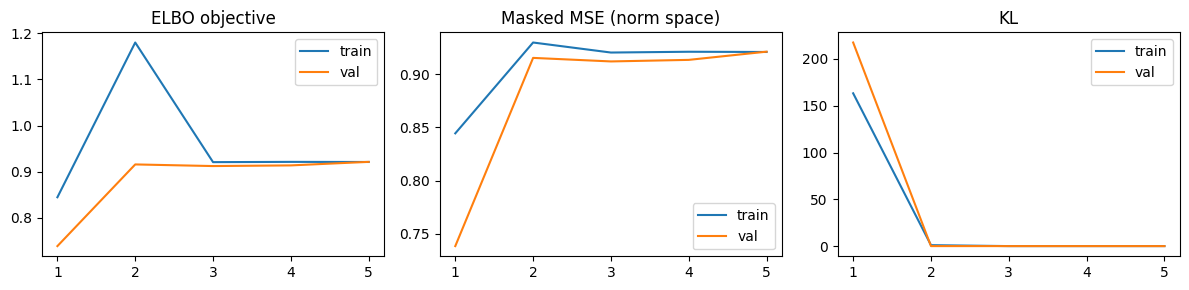

In [37]:
ep = np.arange(1, NUM_EPOCHS + 1)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(ep, history["train_loss"], label="train")
ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("ELBO objective")
ax[0].legend()
ax[1].plot(ep, history["train_recon"], label="train")
ax[1].plot(ep, history["val_recon"], label="val")
ax[1].set_title("Masked MSE (norm space)")
ax[1].legend()
ax[2].plot(ep, history["train_kl"], label="train")
ax[2].plot(ep, history["val_kl"], label="val")
ax[2].set_title("KL")
ax[2].legend()
plt.tight_layout()
plt.show()

## Evaluation by missing-quadrant count

For **k quadrants missing**, **4 − k** are visible. Metrics on **missing pixels** in **denormalized** $[0,1]$ space (MSE / L1 / PSNR with MAX=1).

In [38]:
def metrics_missing_region(x_hat, x, obs_mask, eps=1e-8):
    pred_mask = (1.0 - obs_mask).view(x.size(0), C, H, W)
    xh = flat_to_chw(x_hat)
    xt = flat_to_chw(x)
    xh01 = denorm_cifar(xh)
    xt01 = denorm_cifar(xt)
    diff = (xh01 - xt01) * pred_mask
    denom_m = pred_mask.sum(dim=(1, 2, 3)).clamp(min=1.0)
    mse = ((diff ** 2).sum(dim=(1, 2, 3)) / denom_m).mean().item()
    l1 = (diff.abs().sum(dim=(1, 2, 3)) / denom_m).mean().item()
    psnr = (
        10.0
        * torch.log10(
            1.0 / (((diff ** 2).sum(dim=(1, 2, 3)) / denom_m).clamp(min=eps))
        )
    ).mean().item()
    return mse, l1, psnr


@torch.no_grad()
def evaluate_missing_levels(loader):
    model.eval()
    keys = {}
    for miss in (1, 2, 3):
        keys[miss] = {"mse": 0.0, "l1": 0.0, "psnr": 0.0, "n": 0}

    for imgs, labels in loader:
        x = imgs.view(imgs.size(0), -1).to(DEVICE)
        y = labels.to(DEVICE)
        for miss in (1, 2, 3):
            nv = 4 - miss
            qbits = sample_quadrant_pattern_visible(imgs.size(0), nv, DEVICE)
            obs = pixel_obs_mask_from_quads(qbits, DEVICE)
            x_enc = torch.cat([x * obs, obs], dim=1)
            c = condition_vector(y)
            x_hat, mu, logvar = model(x_enc, c)
            mse, l1, psnr = metrics_missing_region(x_hat, x, obs)
            keys[miss]["mse"] += mse
            keys[miss]["l1"] += l1
            keys[miss]["psnr"] += psnr
            keys[miss]["n"] += 1

    rows = []
    for miss in (1, 2, 3):
        d = keys[miss]
        k = max(d["n"], 1)
        rows.append(
            {
                "missing_quadrants": miss,
                "visible_quadrants": 4 - miss,
                "mse_missing_denorm": d["mse"] / k,
                "l1_missing_denorm": d["l1"] / k,
                "psnr_missing_denorm": d["psnr"] / k,
            }
        )
    return rows


results = evaluate_missing_levels(test_loader)
for r in results:
    print(
        f"Missing {r['missing_quadrants']} quad(s) ({r['visible_quadrants']} visible): "
        f"MSE={r['mse_missing_denorm']:.6f}  L1={r['l1_missing_denorm']:.6f}  "
        f"PSNR={r['psnr_missing_denorm']:.2f} dB"
    )

Missing 1 quad(s) (3 visible): MSE=0.057330  L1=0.196998  PSNR=13.38 dB
Missing 2 quad(s) (2 visible): MSE=0.057353  L1=0.197056  PSNR=13.17 dB
Missing 3 quad(s) (1 visible): MSE=0.057570  L1=0.197457  PSNR=13.09 dB


## Qualitative comparison (denormalized blend)

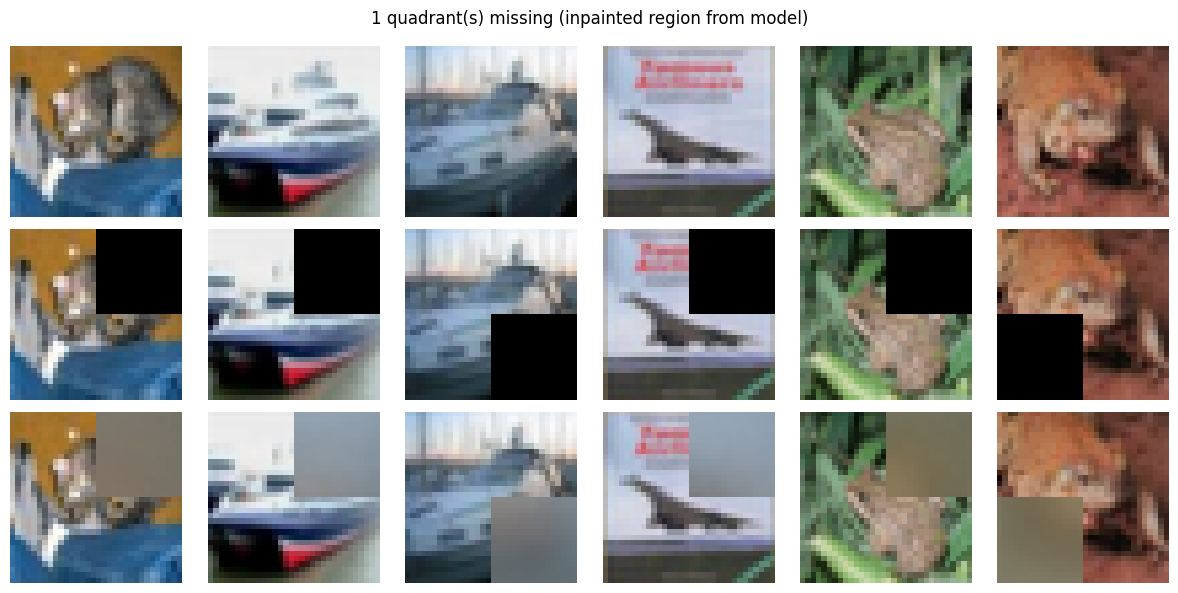

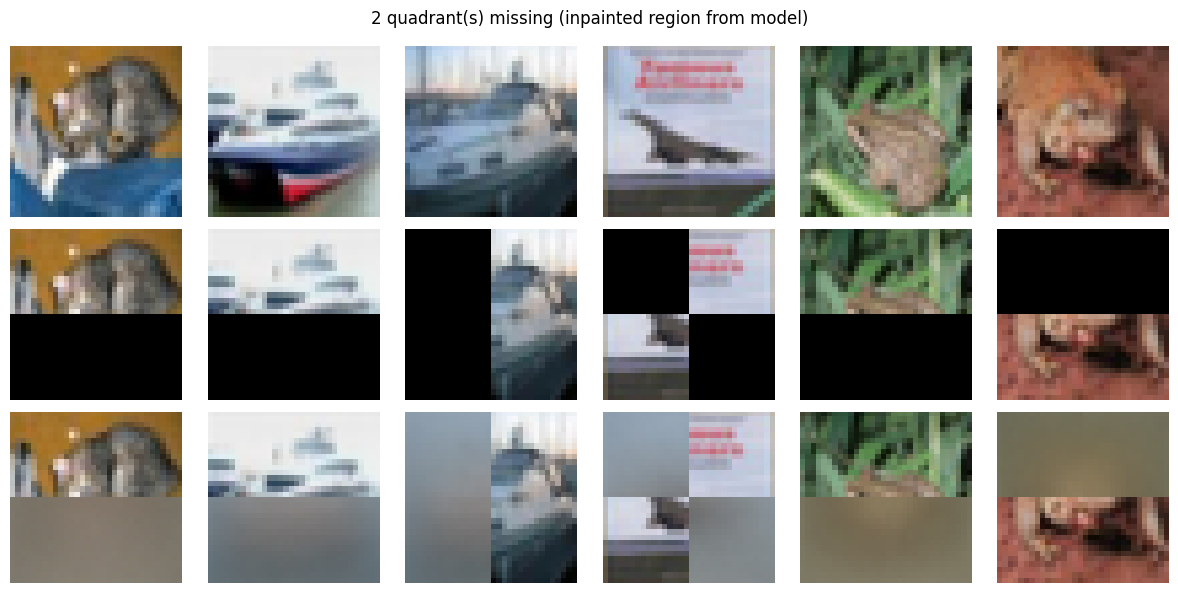

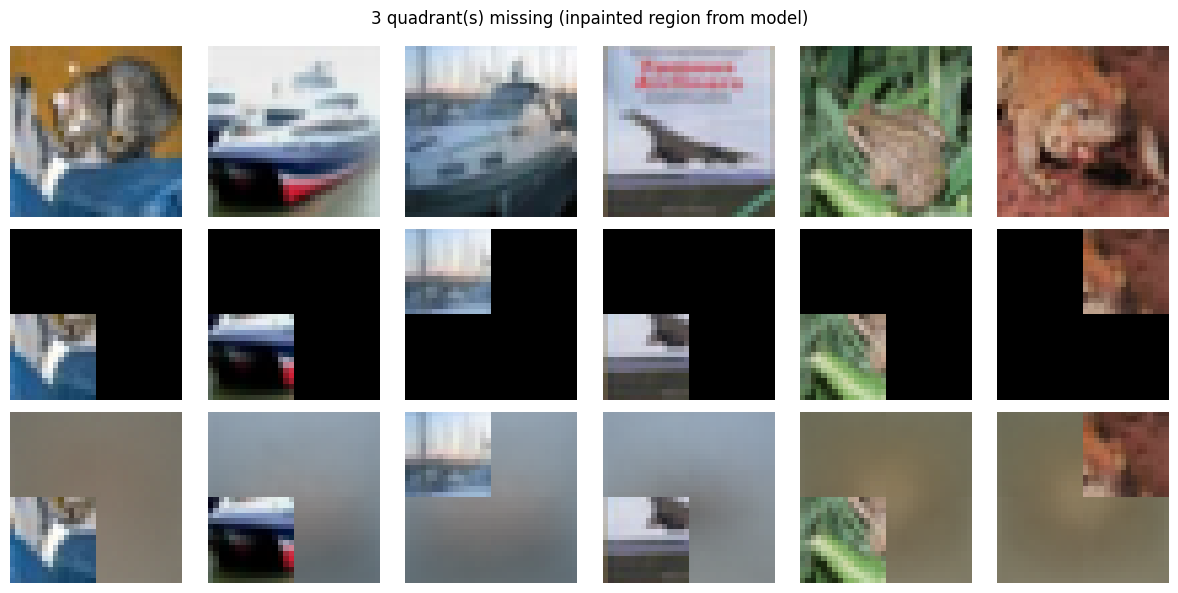

In [39]:
model.eval()


@torch.no_grad()
def plot_row_for_missing(miss, num=6, seed=0):
    torch.manual_seed(seed)
    imgs, labels = next(iter(test_loader))
    imgs, labels = imgs[:num].to(DEVICE), labels[:num].to(DEVICE)
    x = imgs.view(num, -1)
    nv = 4 - miss
    qbits = sample_quadrant_pattern_visible(num, nv, DEVICE)
    obs_flat = pixel_obs_mask_from_quads(qbits, DEVICE)
    obs3 = obs_flat.view(num, C, H, W)
    x_enc = torch.cat([x * obs_flat, obs_flat], dim=1)
    c = condition_vector(labels)
    x_hat, _, _ = model(x_enc, c)
    xh = denorm_cifar(flat_to_chw(x_hat))
    xt = denorm_cifar(imgs)
    comp = obs3 * xt + (1 - obs3) * xh

    fig, axes = plt.subplots(3, num, figsize=(2 * num, 6))
    for i in range(num):
        axes[0, i].imshow(xt[i].cpu().permute(1, 2, 0).numpy())
        axes[0, i].axis("off")
        m = (obs3[i] * xt[i]).cpu().permute(1, 2, 0).numpy()
        axes[1, i].imshow(np.clip(m, 0, 1))
        axes[1, i].axis("off")
        axes[2, i].imshow(comp[i].cpu().permute(1, 2, 0).numpy())
        axes[2, i].axis("off")
    axes[0, 0].set_ylabel("Target", rotation=90)
    axes[1, 0].set_ylabel("Visible", rotation=90)
    axes[2, 0].set_ylabel("Blend", rotation=90)
    plt.suptitle(f"{miss} quadrant(s) missing (inpainted region from model)")
    plt.tight_layout()
    plt.show()


for miss in (1, 2, 3):
    plot_row_for_missing(miss, num=6, seed=123)